<a href="https://colab.research.google.com/github/pabloRnt/machine-learning_SERS/blob/main/SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **10/09 Machine Learning e Energia**

## Exercício

Treinar um modelo de classificação da estabilidade de uma rede elétrica.
Fonte: https://raw.githubusercontent.com/pabloRnt/machine-learning_SERS/refs/heads/main/Data_for_UCI_named.csv

### Preparação do ambiente

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

''' Machine Learning
Algoritmos do sklearn para classificação:'''

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

''' Separação dos dados de| treino e teste
X_train, X_test, y_train, y_test'''
from sklearn.model_selection import train_test_split

# Métricas para classificação
from sklearn.metrics import accuracy_score # Acurácia
from sklearn.metrics import confusion_matrix # Identificação de onde o modelo errou
from sklearn.metrics import classification_report # Resumo de métricas

### Carregar os dados e gerar um Dataframe

In [ ]:
dados = pd.read_csv('https://raw.githubusercontent.com/pabloRnt/machine-learning_SERS/refs/heads/main/Data_for_UCI_named.csv')

In [ ]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


### Análise exploratória

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [ ]:
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [ ]:
dados.describe(include = "object") # Somente estatísticas de atributos categóricos

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [ ]:
# Checando quantidade de classes da coluna alvo (stabf)
dados.stabf.unique()

array(['unstable', 'stable'], dtype=object)

In [ ]:
# Chacando a quantidade de valores de cada classe da coluna alvo (stabf)
dados.stabf.value_counts()

''' Checamos a distribuição das classes para podermos gerar uma amostra estratificada, e não aleatória '''


' Checamos a distribuição das classes para podermos gerar uma amostra estratificada, e não aleatória '

### Sepaeração de dados

In [ ]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [ ]:
# Features
X = dados.drop(['stab', 'stabf'], axis = 1)

In [ ]:
# Variável alvo (target)
y = dados.stabf
y.head()

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable


In [ ]:
# Renomeando as classes da coluna alvo stabf
y = y.map({'stable': 'estável', 'unstable': 'instável'})

#### Separação de dados de treino e teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) # random_state é a identificação da amostra aleatória
# Para obtermos amostras estratificadas, adicionamos o parâmetro strattify = y

In [ ]:
print(X.shape, X_train.shape)
print(y.shape, y_train.shape)

(10000, 12) (8000, 12)
(10000,) (8000,)


## Treinamento e geração das previsões do modelo

In [ ]:
# Instanciando o modelo
modelo_LR = LogisticRegression()

In [ ]:
# Treinando o modelo
modelo_LR.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Gerando as previsões
y_predict = modelo_LR.predict(X_test)
y_predict

array(['instável', 'instável', 'instável', ..., 'estável', 'instável',
       'instável'], dtype=object)

## Avaliação do modelo

In [ ]:
# Acurácia
acuracia = accuracy_score(y_test, y_predict)*100
print(f"A acurácia do modelo baseado em Regressão Logística é {acuracia:.2f}%")

A acurácia do modelo baseado em Regressão Logística é 81.70%


In [ ]:
# Matriz de confusão usando o seaborn e matplotlib

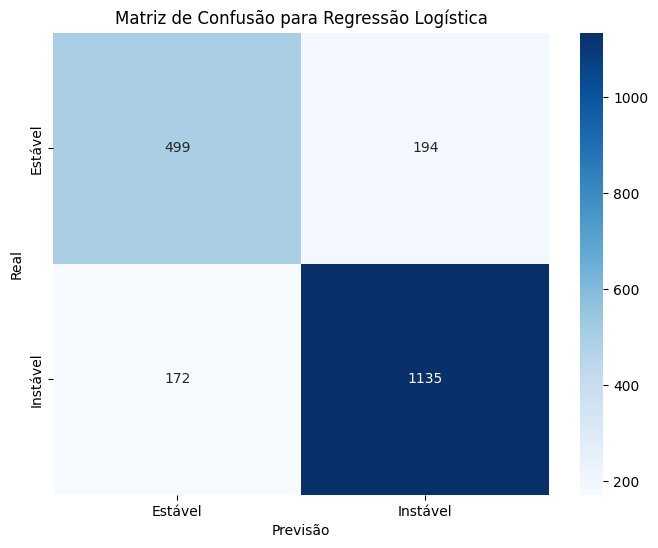

In [ ]:
# Calcular a matriz de confusão
matriz_confusao = confusion_matrix(y_test, y_predict)

# Matriz de confusão usando o seaborn e matplotlib
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Estável', 'Instável'], yticklabels=['Estável', 'Instável'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão para Regressão Logística')
plt.show()

In [ ]:
# Classification Report
report = classification_report(y_test, y_predict)
print(report)

              precision    recall  f1-score   support

     estável       0.74      0.72      0.73       693
    instável       0.85      0.87      0.86      1307

    accuracy                           0.82      2000
   macro avg       0.80      0.79      0.80      2000
weighted avg       0.82      0.82      0.82      2000

